In [43]:
import kagglehub
import os
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, fbeta_score
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from imblearn.metrics import classification_report_imbalanced
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

mpl.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette('cubehelix')

In [44]:
df = pd.read_csv('dataset_malwares.csv')

In [45]:
df.head()

,Name,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
0,VirusShare_a878ba26000edaac5c98eff4432723b3,23117,144,3,0,4,0,65535,0,184,...,3758096608,0,7,152,0,0,54440,77824,73728,0
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0,23117,144,3,0,4,0,65535,0,184,...,3791650880,0,16,311,0,0,262276,294912,0,346112
2,VirusShare_ef84cdeba22be72a69b198213dada81a,23117,144,3,0,4,0,65535,0,184,...,3221225536,0,6,176,0,0,36864,40960,0,0
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e,23117,144,3,0,4,0,65535,0,184,...,3224371328,0,8,155,0,0,356352,1003520,0,14109472
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb,23117,144,3,0,4,0,65535,0,184,...,3227516992,0,2,43,0,0,61440,73728,0,90624


In [46]:
df.shape

(19611, 79)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19611 entries, 0 to 19610
Data columns (total 79 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Name                          19611 non-null  object 
 1   e_magic                       19611 non-null  int64  
 2   e_cblp                        19611 non-null  int64  
 3   e_cp                          19611 non-null  int64  
 4   e_crlc                        19611 non-null  int64  
 5   e_cparhdr                     19611 non-null  int64  
 6   e_minalloc                    19611 non-null  int64  
 7   e_maxalloc                    19611 non-null  int64  
 8   e_ss                          19611 non-null  int64  
 9   e_sp                          19611 non-null  int64  
 10  e_csum                        19611 non-null  int64  
 11  e_ip                          19611 non-null  int64  
 12  e_cs                          19611 non-null  int64  
 13  e

In [48]:
df.drop(columns=['Name'], inplace=True)

In [49]:
df.describe()

,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
count,19611.0,19611.000000,19611.000000,19611.000000,19611.000000,19611.000000,19611.000000,19611.000000,19611.00000,19611.000000,...,1.961100e+04,19611.0,19611.000000,19611.000000,19611.000000,1.961100e+04,1.961100e+04,1.961100e+04,1.961100e+04,1.961100e+04
mean,23117.0,178.615726,71.660752,49.146958,37.370710,37.032635,64178.739687,10.418490,226.46530,29.689103,...,3.163632e+09,0.0,6.112437,101.912804,14.131865,3.368566e+05,4.047213e+05,5.555810e+05,1.238834e+06,8.814868e+05
std,0.0,987.200729,1445.192977,1212.201919,864.515405,915.833139,9110.755873,637.116265,1249.68033,1015.303419,...,5.860332e+08,0.0,7.525158,127.076767,154.958102,2.181191e+07,4.704601e+06,6.772167e+06,5.868961e+07,2.167579e+07
min,23117.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,1.073742e+09,0.0,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,23117.0,144.000000,3.000000,0.000000,4.000000,0.000000,65535.000000,0.000000,184.00000,0.000000,...,3.221226e+09,0.0,2.000000,17.000000,0.000000,0.000000e+00,2.960400e+04,4.096000e+04,0.000000e+00,0.000000e+00
50%,23117.0,144.000000,3.000000,0.000000,4.000000,0.000000,65535.000000,0.000000,184.00000,0.000000,...,3.221226e+09,0.0,4.000000,80.000000,0.000000,0.000000e+00,8.222400e+04,1.310720e+05,0.000000e+00,0.000000e+00
75%,23117.0,144.000000,3.000000,0.000000,4.000000,0.000000,65535.000000,0.000000,184.00000,0.000000,...,3.221226e+09,0.0,8.000000,135.000000,0.000000,0.000000e+00,2.477080e+05,3.870720e+05,0.000000e+00,3.184640e+05
max,23117.0,59448.000000,63200.000000,64613.000000,43690.000000,43690.000000,65535.000000,61436.000000,65464.00000,63262.000000,...,4.294967e+09,0.0,588.000000,4016.000000,7319.000000,2.147484e+09,5.368914e+08,8.304108e+08,2.906159e+09,2.415919e+09


In [50]:
LABELS_FONT_SIZE = 10
TITLE_FONT_SIZE = 12
SUP_TITLE_FONT_SIZE = 20
FONT_WEIGHT = 'bold'
PALETTE = 'BuPu'

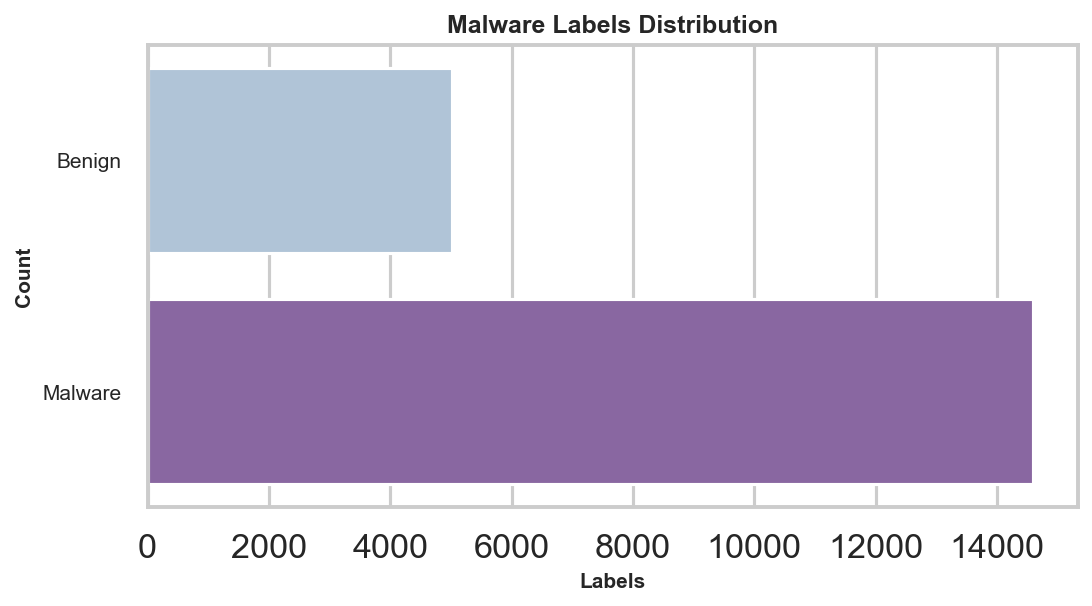

In [51]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='Malware', palette=PALETTE, hue='Malware', legend=False)

plt.title('Malware Labels Distribution', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.yticks([0,1], ['Benign', 'Malware'], fontsize=LABELS_FONT_SIZE)
plt.xlabel('Labels', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.ylabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.show()

In [52]:
X = df.drop('Malware', axis=1)
y = df['Malware']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

print(X_train.shape, X_test.shape)

(15688, 77) (3923, 77)


In [53]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
def create_confusion_matrix(y_true, y_pred, ax):
    cm = confusion_matrix(y_true, y_pred)
    
    ticks_label = ['Benign', 'Malware']
    group_names = ['TN', 'FP', 'FN', 'TP']
    cm_values = [value for value in cm.flatten()]
    cm_labels = [f'{label}\n{val}' for val, label in zip(cm_values, group_names)]
    cm_labels = np.array(cm_labels).reshape([2, 2])
    
    sns.heatmap(cm, annot=cm_labels, fmt='', cmap=PALETTE, ax=ax, xticklabels=ticks_label, yticklabels=ticks_label)
    ax.set_title('Confusion Matrix', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.set_xlabel('Predicted Label', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.set_ylabel('True Label', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    
def create_pr_curve(y_true, y_pred, ax):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    
    sns.lineplot(x=recall, y=precision, ax=ax, palette=PALETTE)
    ax.set_title('Precision-Recall Curve', fontsize=TITLE_FONT_SIZE)
    ax.set_xlabel('Recall', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.set_ylabel('Precision', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

<p>
The <b>create_confusion_matrix</b> function generates a visual representation of a model’s predictions using a confusion matrix. It compares the true labels (<code>y_true</code>) with the predicted labels (<code>y_pred</code>) and organizes the results into four categories: True Negative (TN), False Positive (FP), False Negative (FN), and True Positive (TP). The values are displayed using a Seaborn heatmap, with clear labels for the classes (<b>Benign</b> and <b>Malware</b>) and annotated counts in each cell to make the model’s performance easier to interpret.

</p>

<p>

The <b>create_pr_curve</b> function plots a Precision–Recall curve to evaluate classification performance, especially for imbalanced datasets. It computes precision and recall values using <code>precision_recall_curve()</code> and visualizes their relationship using a line plot. This curve helps illustrate the trade‑off between correctly detecting positive cases (recall) and maintaining prediction accuracy for positive predictions (precision).
</p>

In [55]:
def hyper_parameters_tuning(X, y, base_model, params_grid, iterations=50, cv=5, n_jobs=None):
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=params_grid,
        n_iter=iterations,
        scoring='average_precision',
        cv=cv, n_jobs=n_jobs,
        random_state=42
    )
    
    random_search.fit(X, y)

    best_estimator = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = random_search.best_score_
    
    return best_estimator, best_params, best_score 

<p>
The <b>hyper_parameters_tuning</b> function uses <code>RandomizedSearchCV</code> to find the best hyperparameters for a given machine learning model. It randomly tests several parameter combinations from <code>params_grid</code> and evaluates them using cross‑validation with the <code>f1_macro</code> metric.

</p>

<p>
After the search is complete, it returns the best trained model, the best parameter configuration, and the corresponding cross‑validation score.
</p>

<h1>Training Models</h1>

<h3>1. Train Models</h3>

<p>Train several ML models on the training data and optimize them using cross‑validation.</p>

<h3>2. Choose the Best Model</h3>

<p>Compare their results and select the model with the highest performance</p>

In [56]:
lr = LogisticRegression(random_state=42, solver='saga')

lr_params_dist = {
    "C": loguniform(1e-2, 1e2),
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],
    "max_iter": [2000, 5000, 10000]
}

In [57]:
lr_best_model, lr_best_params, lr_best_score = hyper_parameters_tuning(X_train, y_train, lr, params_grid=lr_params_dist, n_jobs=-1)

print('Best logistic regression parameters: ', lr_best_params)
print('Best logistic regression cv score: ', lr_best_score)

Best logistic regression parameters:  {'C': 37.95853142670641, 'class_weight': 'balanced', 'max_iter': 10000, 'penalty': 'l2'}
Best logistic regression cv score:  0.9905131727860175


In [58]:
knn = KNeighborsClassifier()

knn_param_dist = {
    "n_neighbors": randint(1, 50),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2],
    "leaf_size": randint(10, 60),
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"]
}

In [59]:
knn_best_model, knn_best_params, knn_best_score = hyper_parameters_tuning(X_train, y_train, knn, params_grid=knn_param_dist, n_jobs=-1)

print('Best KNN classifier parameters: ', knn_best_params)
print('Best KNN classifier cv score: ', knn_best_score)

Best KNN classifier parameters:  {'algorithm': 'auto', 'leaf_size': 58, 'metric': 'manhattan', 'n_neighbors': 49, 'p': 2, 'weights': 'distance'}
Best KNN classifier cv score:  0.9950429154331862


In [60]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    device='cuda'
)

xgb_params_dist = {
    "n_estimators": randint(200, 1200),
    "max_depth": randint(3, 12),
    "learning_rate": loguniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_alpha": loguniform(1e-4, 10),
    "reg_lambda": loguniform(1e-3, 10),
    "scale_pos_weight": [1, 2, 3]
}

In [61]:
xgb_best_model, xgb_best_params, xgb_best_score = hyper_parameters_tuning(X_train, y_train, xgb, params_grid=xgb_params_dist)

print('Best xgboost parameters: ', xgb_best_params)
print('Best xgboost cv score: ', xgb_best_score)

Best xgboost parameters:  {'colsample_bytree': 0.871025744736913, 'gamma': 0.08293914463928076, 'learning_rate': 0.05707205898008386, 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 1063, 'reg_alpha': 0.0003026096376086027, 'reg_lambda': 5.782199315538692, 'scale_pos_weight': 3, 'subsample': 0.9746919954946938}
Best xgboost cv score:  0.9993361197113835


<p><code>XGBoost</code> achieved the best overall performance, so the final step is to evaluate this model on the test set.</p>

                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      0.97      1.00      0.98      0.98      0.96      1003
          1       0.99      1.00      0.97      0.99      0.98      0.97      2920

avg / total       0.99      0.99      0.98      0.99      0.98      0.97      3923

Average Precision: 0.9886498918111811
F2 Score Macro: 0.9851558477662318


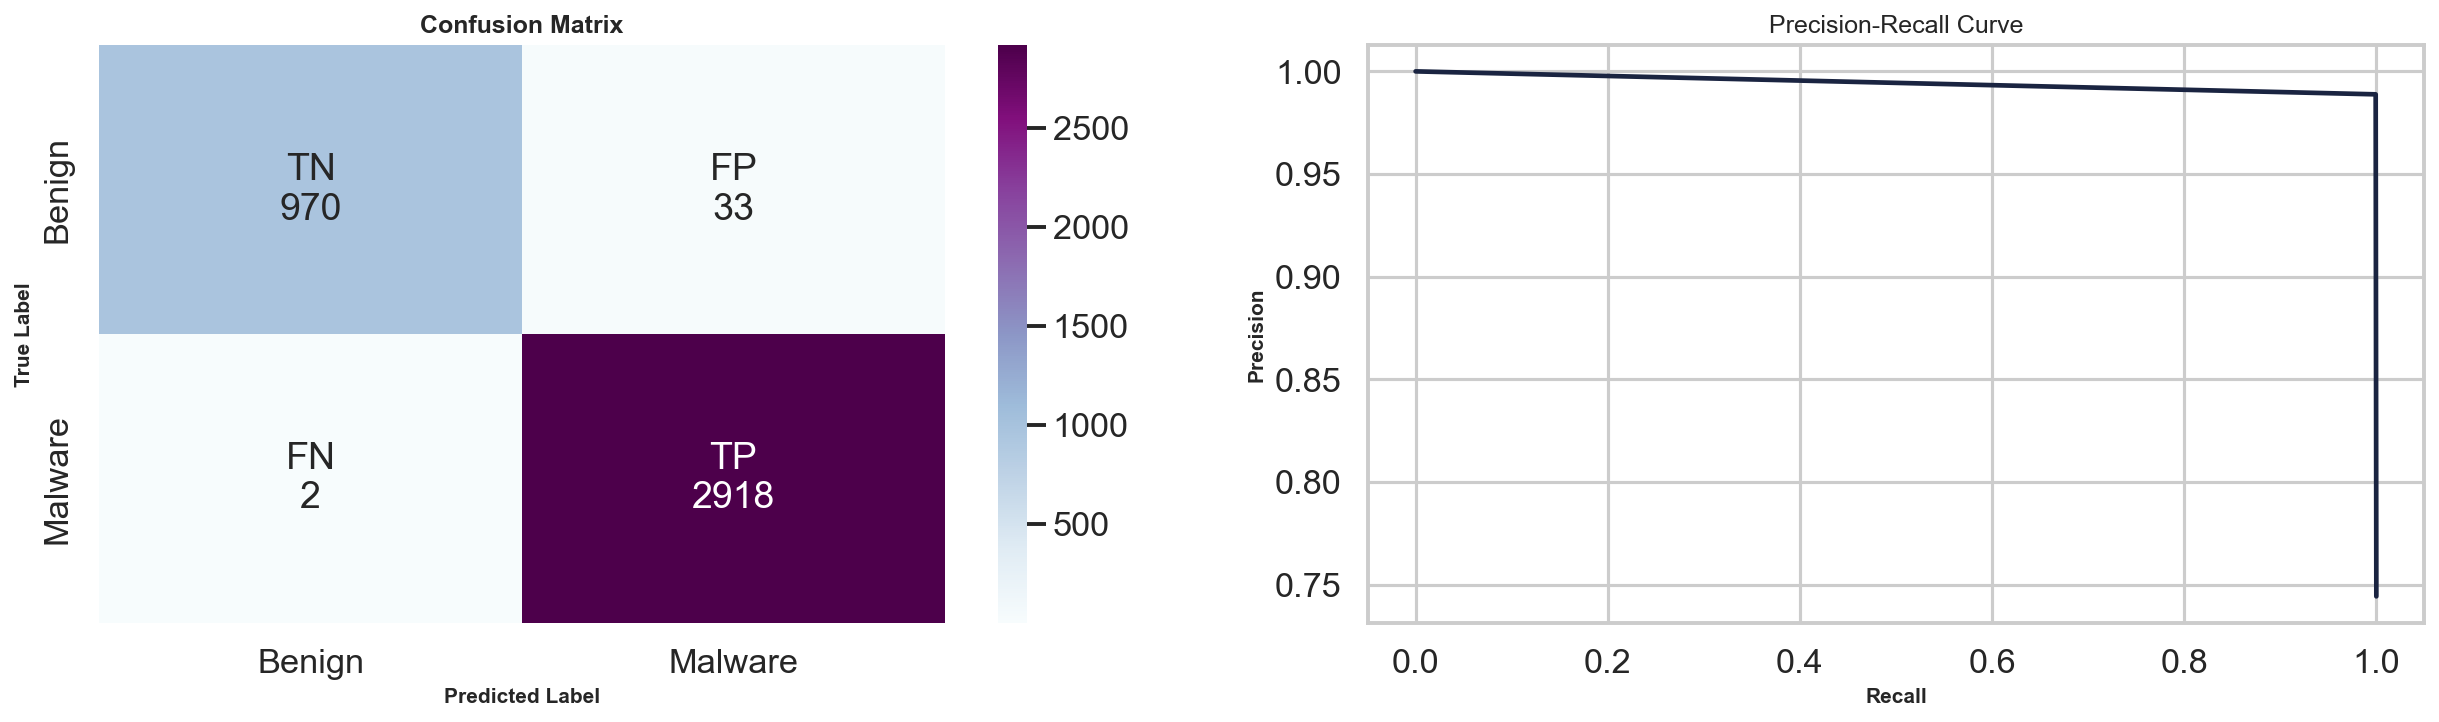

In [62]:
y_pred = xgb_best_model.predict(X_test)

print(classification_report_imbalanced(y_test, y_pred))
print('Average Precision:', average_precision_score(y_test, y_pred, average='macro'))
print('F2 Score Macro:', fbeta_score(y_test, y_pred, beta=2, average='macro'))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
axes = axes.flatten()
create_confusion_matrix(y_test, y_pred, ax=axes[0])
create_pr_curve(y_test, y_pred, ax=axes[1])
plt.show()

<h2>Final Model Selection and Evaluation</h2>


<p>Since <code>XGBoost</code> showed the best overall performance among the evaluated models, it was selected as the final model. In the following section, we implement the final evaluation process step by step.

First, feature selection is performed using the feature importance scores obtained from the trained <code>XGBoost</code> model. This step removes less relevant features and keeps the most informative ones.

Next, the <code>XGBoost</code> model is retrained using the selected features to build the final version of the model.

Finally, the trained model is evaluated on the test dataset to measure its performance on previously unseen data.</p>


In [63]:
selector = SelectFromModel(estimator=xgb_best_model, threshold='median')

selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

In [64]:
xgb_best_model.fit(X_train_selected, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.871025744736913, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.08293914463928076, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05707205898008386,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1063, n_jobs=None,
              num_parallel_tree=None, ...)

In [65]:
cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

cross = cross_val_score(
    xgb_best_model, 
    X_train_selected, 
    y_train, cv=cv, 
    n_jobs=-1,
    scoring='average_precision'
)

print('Total Scores:', cross, '\n')
print('Average Scores:', cross.mean())

Total Scores: [0.99964567 0.99774226 0.99959615 0.99983527 0.9999443  0.99908878
 0.9997035  0.99861574 0.99942366 0.9991036 ] 

Average Scores: 0.9992698938883133


                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      0.97      1.00      0.98      0.98      0.96      1003
          1       0.99      1.00      0.97      0.99      0.98      0.97      2920

avg / total       0.99      0.99      0.98      0.99      0.98      0.97      3923

Average Precision(after feature selection): 0.98898485454945
F2 Score Macro(after feature selection): 0.9855938286493109


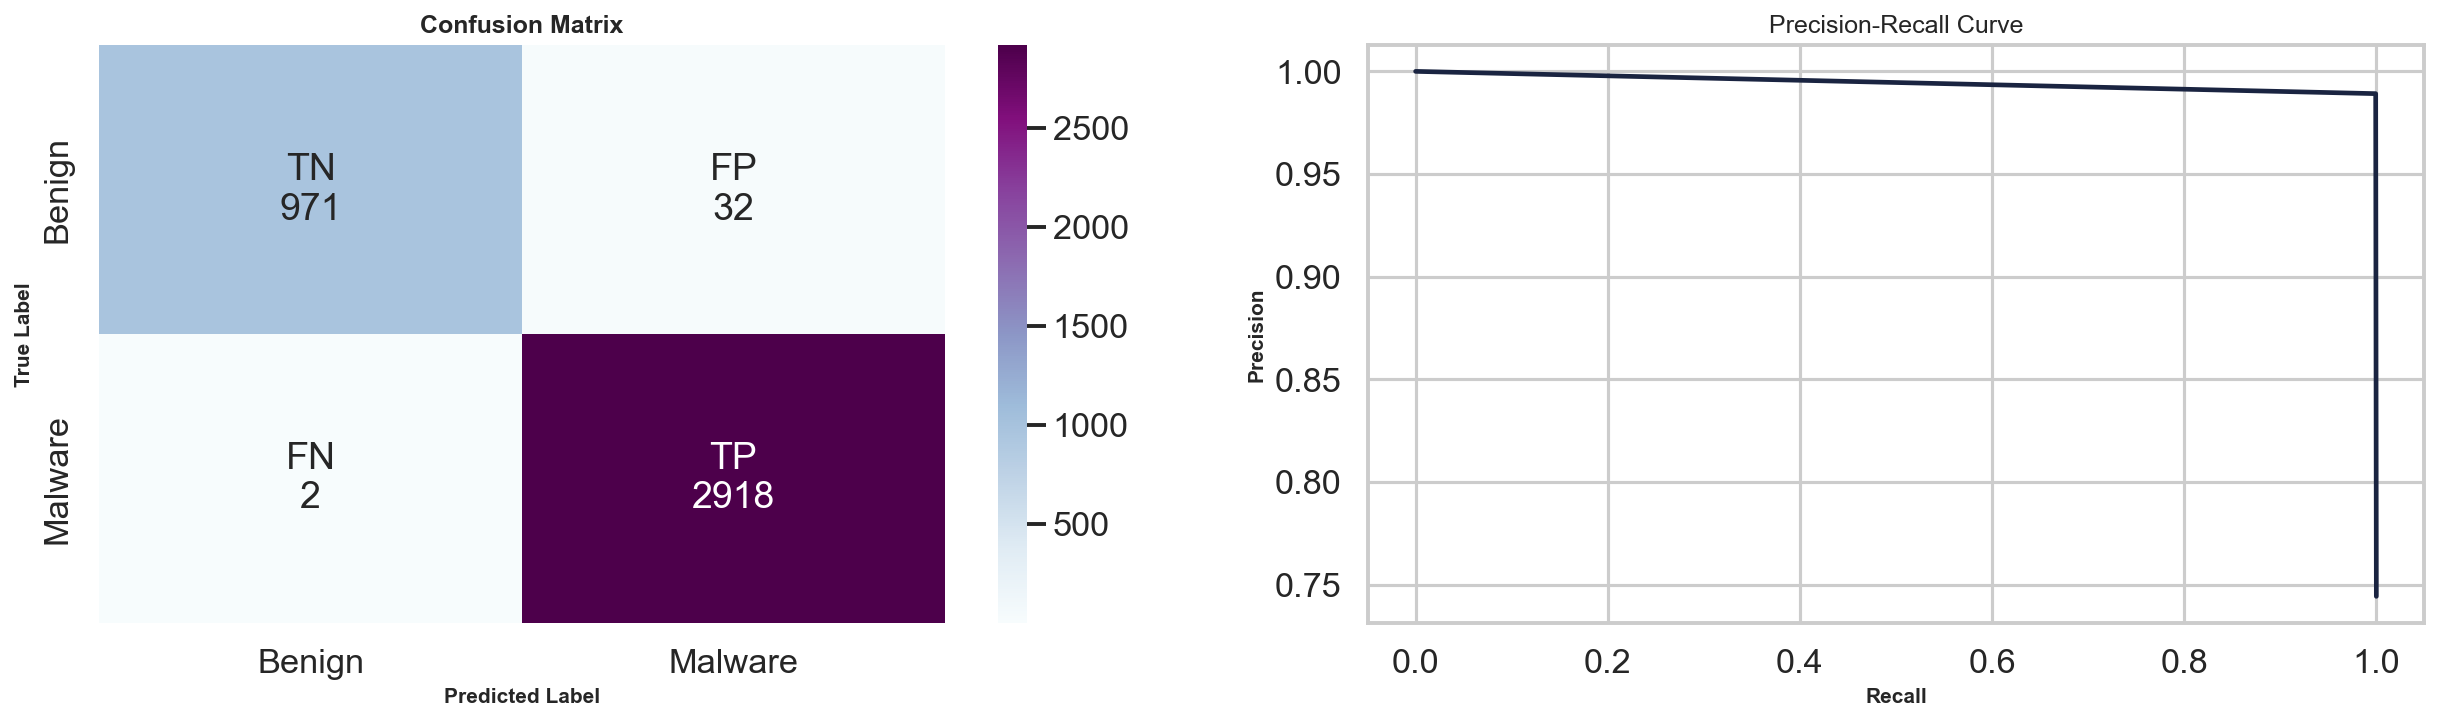

In [66]:
y_pred = xgb_best_model.predict(X_test_selected)

print(classification_report_imbalanced(y_test, y_pred))
print('Average Precision(after feature selection):', average_precision_score(y_test, y_pred, average='macro'))
print('F2 Score Macro(after feature selection):', fbeta_score(y_test, y_pred, beta=2, average='macro'))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
axes = axes.flatten()
create_confusion_matrix(y_test, y_pred, ax=axes[0])
create_pr_curve(y_test, y_pred, ax=axes[1])
plt.show()